In [82]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Spike-in Analysis

In [83]:
import pysam
import numpy as np
import pandas as pd
import tqdm

from fragmentomics_tools.plot.tracks import VectorTracks, Tracks
from fragments_h5.fragment import bam_to_fragments

In [86]:
fa = pysam.Fastafile("/scratch/karius/short_read_mapping/spikein.fa")
# reads = pysam.AlignmentFile("/scratch/karius/short_read_mapping/bowtie/mappped.sorted.bam")
reads = pysam.AlignmentFile("/scratch/karius/short_read_mapping/ECs/mapped.sorted.bam")

In [87]:
ref_df = pd.DataFrame(dict(ref=fa.references, len=fa.lengths)).query("len >= 50 and not ref.str.startswith('ID')").sort_values('len')

In [88]:
ref_df

,ref,len
314,RNA_Oligo_1,50
315,RNA_Oligo_2,50
14,SPARK-052-20GC-01-v1,52
46,SPARK-SLAP-RE,52
50,spark-052,52
...,...,...
360,v4-175-50-ss-01,175
55,spark-175,175
35,SPARK-175-3b-v1,175
56,spark-350,350


In [89]:
def make_track(cov):
    track = VectorTracks(
        [start_cov['-'][5:-5], start_cov['+'][5:-5], stop_cov['-'][5:-5], stop_cov['+'][5:-5]],
        Region('NA', 0, len(seq)-10),
        labels=["Negative Strand Fragment Starts", 'Positive Strand Fragment Starts', 'Negative Strand Fragment Stops', 'Positive Strand Fragment Stops'],
        colors=['red', 'blue', 'orange', 'purple'],
        alpha=0.5,
        ymin=0,
    )
    track.name=contig

def make_cov(contig):
    seq = fa.fetch(contig)
    start_cov = {'+': np.zeros(len(seq)), '-': np.zeros(len(seq))}
    stop_cov = {'+': np.zeros(len(seq)), '-': np.zeros(len(seq))}
    for x in bam_to_fragments(reads, chrom=contig, min_mapq=10):
        if x.length < 20:
            continue
        start_cov[x.strand][x.start] += 1
        stop_cov[x.strand][x.stop-1] += 1
    cov = pd.DataFrame(dict(minus_strand_starts=start_cov['-'], plus_strand_starts=start_cov['+'], minus_strand_ends=stop_cov['-'], plus_strand_ends=stop_cov['+']))
    return cov

In [90]:
%%time
covs = {}
for ref in tqdm.tqdm(ref_df.ref):
    covs[ref] = make_cov(ref)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 105/105 [06:36<00:00,  3.78s/it]

CPU times: user 6min 36s, sys: 768 ms, total: 6min 37s
Wall time: 6min 36s


In [94]:
refs = """
v4-100-50-ss-01
SPARK-125-3a-v1
v4-125-50-ss-01
SPARK-150-3a-v1
v4-150-50-ds-02
v4-150-50-ss-01
SPARK-175-3a-v1
v4-175-50-ss-01
""".strip().splitlines()
refs

['v4-100-50-ss-01',
 'SPARK-125-3a-v1',
 'v4-125-50-ss-01',
 'SPARK-150-3a-v1',
 'v4-150-50-ds-02',
 'v4-150-50-ss-01',
 'SPARK-175-3a-v1',
 'v4-175-50-ss-01']

In [95]:
def plot(ref, ax=None):
    ax = covs[ref].iloc[5:-5, :].plot.line(ax=axarr[i])
    counts = pd.concat(dict(total=covs[ref].sum().astype(int), partial_fragments=covs[ref].iloc[5:-5, :].sum().astype(int)), axis=1)
    counts['fraction'] = round(100*counts.partial_fragments/counts.total, 2)
    ax.text(int(ax.get_xlim()[1]*0.55), int(ax.get_ylim()[1]*0.53), str(counts.sort_index()), fontfamily='monospace')
    ax.set_title(ref)
    return ax

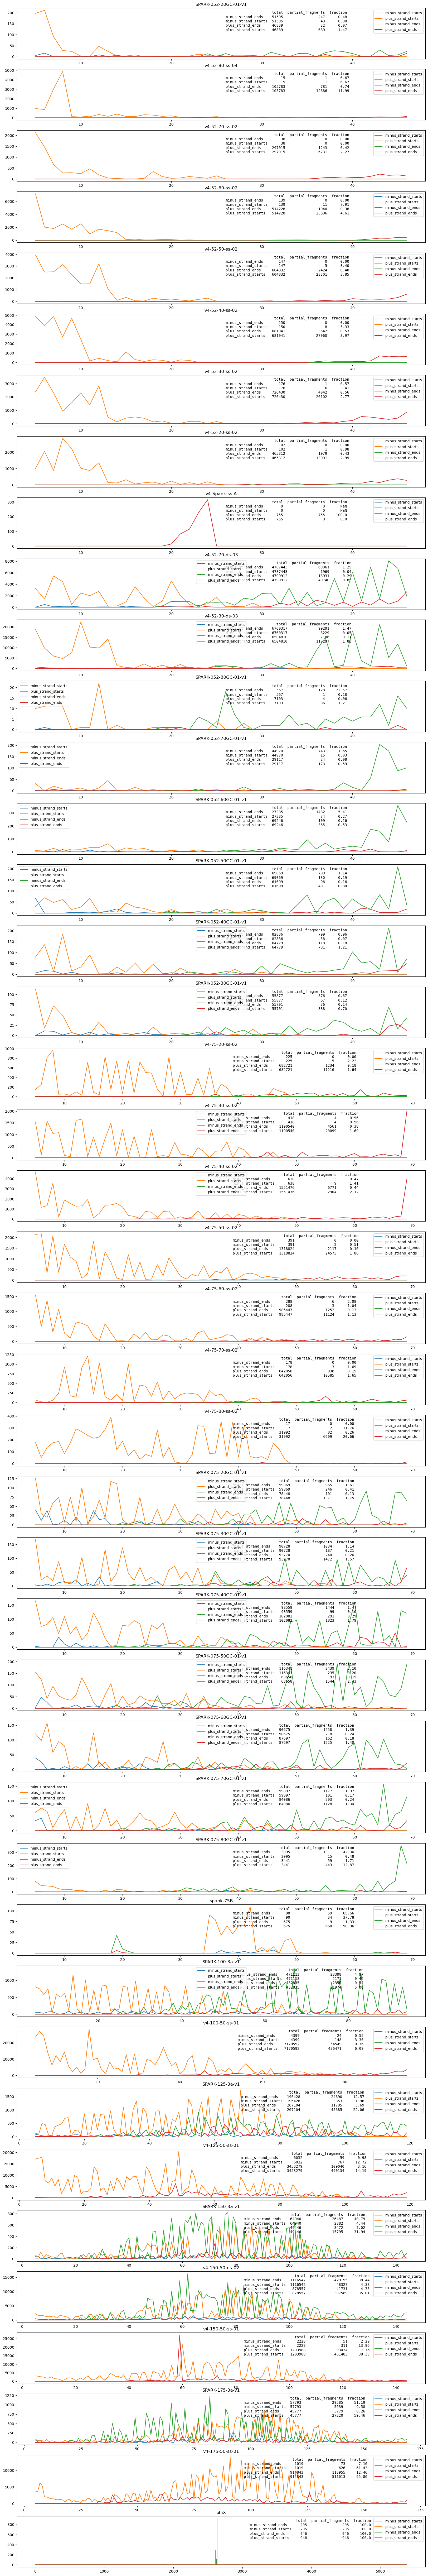

In [96]:
import matplotlib

n = sum(1 for cov in covs.values() if cov.sum().sum() >= 1000)
fig, axarr = matplotlib.pyplot.subplots(n, figsize=(20, 3*n))
i = 0
for ref in covs.keys():
    if covs[ref].sum().sum() < 1000: continue
    axarr[i] = plot(ref)
    i += 1

In [ ]:
fig.show()

In [79]:
def plot_full(ref):
    ax = covs[ref].plot(figsize=(20,5))
    counts = pd.concat(dict(total=covs[ref].sum().astype(int), partial_fragments=covs[ref].iloc[5:-5, :].sum().astype(int)), axis=1)
    counts['fraction'] = round(100*counts.partial_fragments/counts.total, 2)
    ax.text(int(ax.get_xlim()[1]*0.55), int(ax.get_ylim()[1]*0.76), str(counts.sort_index()), fontfamily='monospace')
    ax.set_title(ref)
    return ax

<Axes: title={'center': 'v4-100-50-ss-01'}>

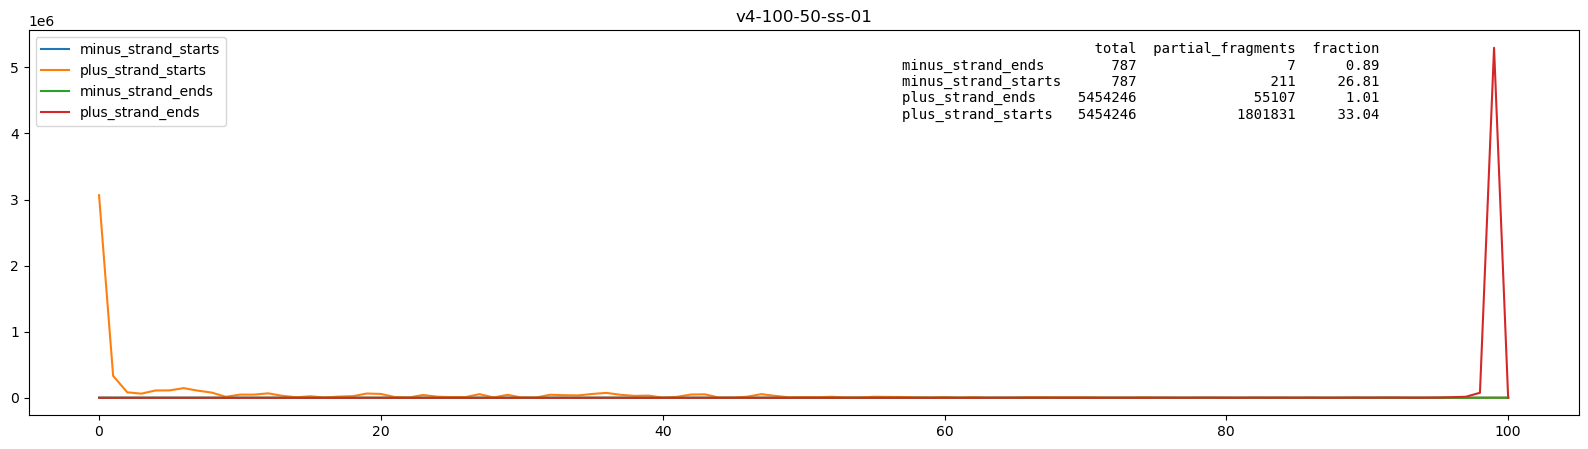

In [81]:
plot_full('v4-100-50-ss-01')

In [195]:
cov

,start_minus,start_plus,stop_minus,stop_plus
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0
...,...,...,...,...
5381,0.0,0.0,0.0,0.0
5382,0.0,0.0,0.0,0.0
5383,0.0,0.0,0.0,0.0
5384,0.0,0.0,0.0,0.0


In [196]:
fa.fetch('phiX', 2604, 2635)

'CAGGTTGTTTCTGTTGGTGCTGATATTGCTT'

<Axes: >

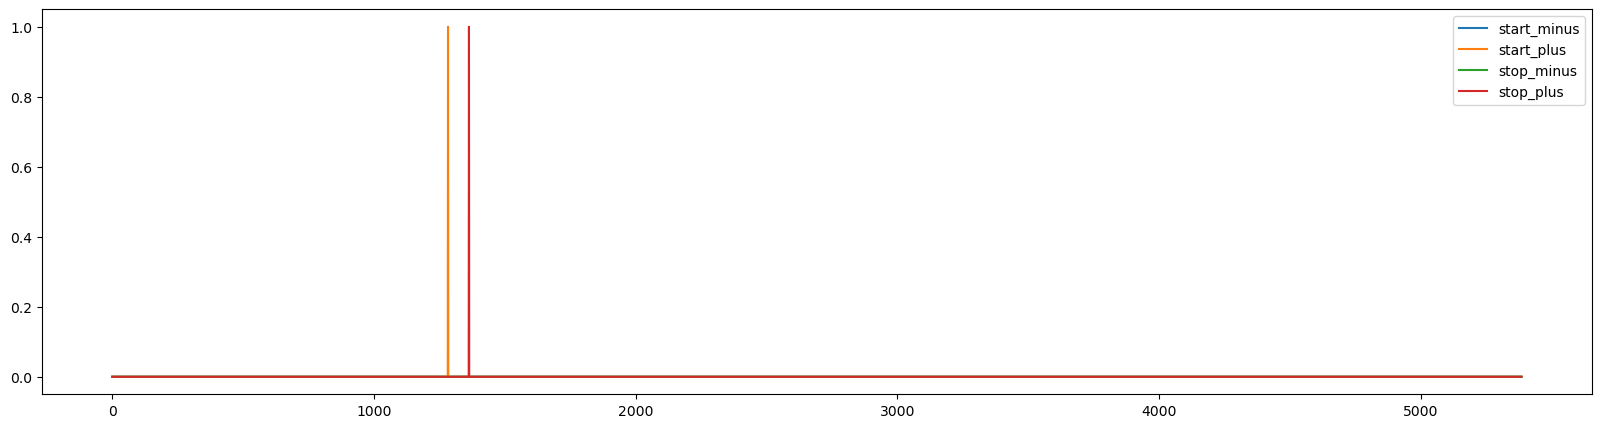

In [198]:
cov.plot(figsize=(20, 5))

In [166]:
VectorTrack(cov['+'][2605:2800])

VectorTrack(input=array([ 0.,  0.,  0.,  0.,  3., 33., 26., 19., 17., 16., 21.,  4., 40.,
        3.,  1.,  1.,  6.,  0.,  2.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,
        1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,
        0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  2.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,